In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df = pd.read_parquet('../data/interim/noise_hourly_avg.parquet')
df.head()

,datetime_hour,sensor_id,avg_noise_level,num_measurements
0,2015-01-01 07:00:00+00:00,186,74.3,1
1,2015-01-01 07:00:00+00:00,187,68.6,1
2,2015-01-01 08:00:00+00:00,186,67.4,1
3,2015-01-01 08:00:00+00:00,187,65.0,1
4,2015-01-01 09:00:00+00:00,186,63.2,1


In [3]:
min_time = df["datetime_hour"].min()
max_time = df["datetime_hour"].max()

full_range = pd.date_range(start=min_time, end=max_time, freq="H")
print(f"⏱️ Rango horario total: {len(full_range):,} horas ({min_time} → {max_time})")

sensors = df["sensor_id"].unique()
full_index = pd.MultiIndex.from_product(
    [full_range, sensors],
    names=["datetime_hour", "sensor_id"]
)

df_full = pd.DataFrame(index=full_index).reset_index()

⏱️ Rango horario total: 92,753 horas (2015-01-01 07:00:00+00:00 → 2025-07-31 23:00:00+00:00)


In [4]:
df_merged = df_full.merge(df, on=["datetime_hour", "sensor_id"], how="left")

In [5]:
import pandas as pd

# Ensure datetime column is in datetime format
df_merged["datetime_hour"] = pd.to_datetime(df_merged["datetime_hour"], errors="coerce")

# 1️⃣ Add a "year" column
df_merged["year"] = df_merged["datetime_hour"].dt.year

# 2️⃣ Global missing ratio per year
missing_ratio_by_year = (
    df_merged.groupby("year")["avg_noise_level"]
    .apply(lambda x: x.isna().mean())
    .to_frame(name="missing_ratio")
)

print("Global missing ratio by year:")
print(missing_ratio_by_year)

Global missing ratio by year:
      missing_ratio
year               
2015       0.987416
2016       0.931328
2017       0.904292
2018       0.883012
2019       0.857171
2020       0.865471
2021       0.854546
2022       0.843579
2023       0.815860
2024       0.815620
2025       0.790735


<Axes: xlabel='year'>

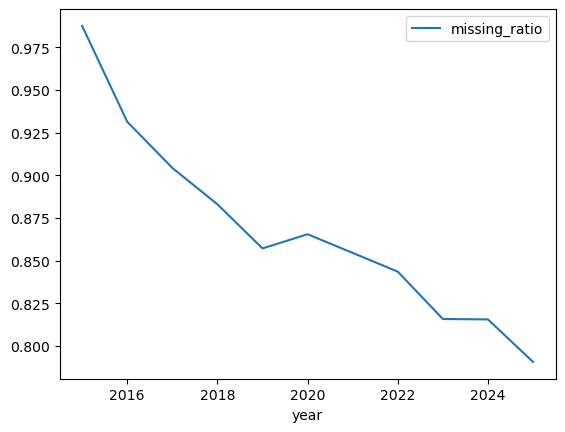

In [6]:
missing_ratio_by_year.plot()

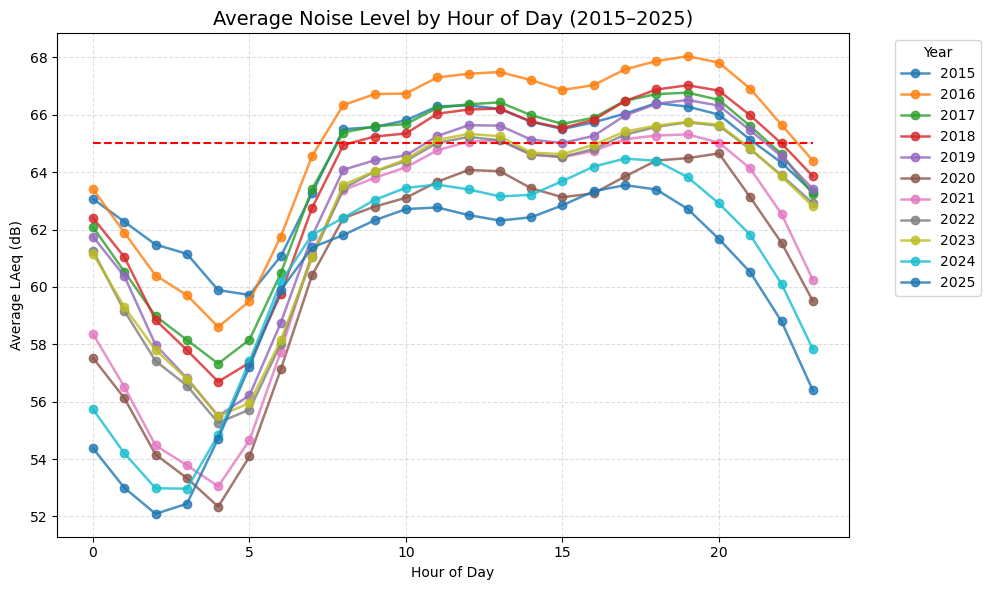

In [7]:
# Extract year and hour of day
df_merged["year"] = df_merged["datetime_hour"].dt.year
df_merged["hour"] = df_merged["datetime_hour"].dt.hour

# Compute average LAeq (dB) per hour of day for each year
avg_noise_hour_year = (
    df_merged.groupby(["year", "hour"])["avg_noise_level"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

for year, group in avg_noise_hour_year.groupby("year"):
    plt.plot(group["hour"], group["avg_noise_level"], 
             marker="o", linewidth=1.8, alpha=0.8, label=str(year))

plt.title("Average Noise Level by Hour of Day (2015–2025)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Average LAeq (dB)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.hlines(y=65, xmin=0, xmax=23, color='r', linestyle='--', label='Noise Limit (65 dB)')
plt.tight_layout()
plt.show()


In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

# Ensure datetime format
df_merged["datetime_hour"] = pd.to_datetime(df_merged["datetime_hour"], errors="coerce")

# --- Helper function: max consecutive missing hours ---
def max_gap_hours(series):
    missing = series.isna()
    return (
        missing.astype(int)
        .groupby(missing.ne(missing.shift()).cumsum())
        .sum()
        .max()
    )

# --- Compute quality metrics per sensor ---
sensor_quality = (
    df_merged.groupby("sensor_id")
    .agg(
        missing_ratio=("avg_noise_level", lambda x: x.isna().mean()),
        max_gap_hours=("avg_noise_level", max_gap_hours),
        mean_noise=("avg_noise_level", "mean"),
        first_year=("datetime_hour", lambda x: x.min().year if not x.isna().all() else np.nan),
        last_year=("datetime_hour", lambda x: x.max().year if not x.isna().all() else np.nan),
        total_records=("avg_noise_level", "count")
    )
    .reset_index()
)

# Add percentage column
sensor_quality["missing_ratio_pct"] = (sensor_quality["missing_ratio"] * 100).round(2)

# Sort by missing ratio (worst sensors first)
sensor_quality = sensor_quality.sort_values("missing_ratio", ascending=False)

print("📊 Sensor Quality Summary:")
print(sensor_quality.head(10))

# --- Save output ---
output_path = Path("data/processed/sensor_quality_summary.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
sensor_quality.to_csv(output_path, index=False)
print(f"💾 Saved to {output_path}")


📊 Sensor Quality Summary:
     sensor_id  missing_ratio  max_gap_hours  mean_noise  first_year  \
746       9772       0.999989          87161   50.800000        2015   
174       2054       0.999978          73814   61.350000        2015   
175       2055       0.999978          73822   28.050000        2015   
75         846       0.999968          81873   71.666667        2015   
202       2489       0.999925          70061   62.600000        2015   
495       6667       0.999914          65040   67.075000        2015   
678       8726       0.999827          78480   63.668750        2015   
649       8386       0.999817          76433   64.464706        2015   
709       9226       0.999784          85442   52.055000        2015   
153       1926       0.999763          74606   73.681818        2015   

     last_year  total_records  missing_ratio_pct  
746       2025              1             100.00  
174       2025              2             100.00  
175       2025              

In [10]:
import pandas as pd
from pathlib import Path

# Load your dataset
df = pd.read_parquet("../data/interim/noise_hourly_avg.parquet")

# Ensure datetime format
df["datetime_hour"] = pd.to_datetime(df["datetime_hour"], errors="coerce")

# Determine full time range (hourly)
min_time = df["datetime_hour"].min()
max_time = df["datetime_hour"].max()
full_range = pd.date_range(start=min_time, end=max_time, freq="H")

print(f"Full hourly range: {len(full_range):,} hours ({min_time} → {max_time})")

# Create all combinations of (datetime_hour × sensor_id)
sensors = df["sensor_id"].unique()
full_index = pd.MultiIndex.from_product(
    [full_range, sensors],
    names=["datetime_hour", "sensor_id"]
)

df_full = pd.DataFrame(index=full_index).reset_index()

# Merge original data → missing hours become NaN
df_reindexed = df_full.merge(df, on=["datetime_hour", "sensor_id"], how="left")

# Sanity check
global_missing = df_reindexed["avg_noise_level"].isna().mean()
print(f"🔍 Global missing ratio after reindexing: {global_missing:.2%}")

# Save result for future phases
output_path = Path("data/processed/noise_full_reindexed.parquet")
output_path.parent.mkdir(parents=True, exist_ok=True)
df_reindexed.to_parquet(output_path, index=False)
print(f"Reindexed dataset saved → {output_path}")


🕐 Full hourly range: 92,753 hours (2015-01-01 07:00:00+00:00 → 2025-07-31 23:00:00+00:00)
🔍 Global missing ratio after reindexing: 87.11%
💾 Reindexed dataset saved → data/processed/noise_full_reindexed.parquet
